# NB11: 배송 경로 분석 — 드론·로봇 시뮬레이션

**목적**: 선정 거점에서 핫스팟까지의 드론 비행 경로와 로봇 지상 경로를 시뮬레이션

**분석 내용**:
1. 드론 경로: 직선 비행 + 고도 프로파일
2. 로봇 경로: 도로 네트워크 기반 최단 경로 (경사도 반영)
3. 드론→로봇 핸드오프: Green Zone 경계에서의 인수인계 시뮬레이션
4. 배송 시간·거리 추정

**입력**:
- `processed/final_hubs.gpkg` (NB10)
- `processed/constraint_layers.gpkg` (NB09)
- `processed/seongnam_slope.tif` (NB03)
- `processed/seongnam_dem.tif` (NB03)

**출력**:
- `processed/drone_routes.gpkg` (드론 비행 경로)
- `processed/delivery_routes_summary.csv` (경로별 시간/거리 요약)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import LineString, Point
from pathlib import Path

BASE = Path(r"C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam")
OUT = BASE / "processed"

# 데이터 로드
hubs = gpd.read_file(OUT / "final_hubs.gpkg", layer="hubs")
grid = gpd.read_file(OUT / "constraint_layers.gpkg")
seongnam = gpd.read_file(OUT / "seongnam_boundary.gpkg", layer="dong")

print(f"거점: {len(hubs)}개")
print(f"H3 그리드: {len(grid)} 셀")

거점: 4개
H3 그리드: 1947 셀


## 1. 각 거점의 서비스 대상 핫스팟 매칭

NB10의 greedy 결과를 바탕으로, 각 거점이 담당하는 핫스팟 셀 할당 (최근접 거점 기준)

In [2]:
# 핫스팟 셀 (urgency 상위 30% + composite > 0)
feasible = grid[grid["composite_score"] > 0].copy()
urgency_threshold = feasible["urgency"].quantile(0.70)
hotspots = feasible[feasible["urgency"] >= urgency_threshold].copy()

# 각 핫스팟을 최근접 거점에 할당
hotspot_pts = gpd.GeoDataFrame(
    hotspots[["h3_index", "urgency", "terrain_zone", "avg_slope", "ADM_NM"]],
    geometry=gpd.points_from_xy(hotspots["lon"], hotspots["lat"]),
    crs="EPSG:4326",
).to_crs(epsg=5179)

hub_pts = gpd.GeoDataFrame(
    hubs[["name", "facility", "delivery_mode"]].rename(columns={"name": "hub_name"}),
    geometry=hubs.geometry,
    crs="EPSG:4326",
).to_crs(epsg=5179)

# sjoin_nearest로 최근접 거점 매칭
assigned = gpd.sjoin_nearest(hotspot_pts, hub_pts, how="left", distance_col="dist_to_hub")

print(f"핫스팟 {len(hotspots)} 셀 → {len(hubs)} 거점 할당 완료")
print(f"\n거점별 할당 셀 수:")
print(assigned.groupby("hub_name")["h3_index"].count().sort_values(ascending=False))

핫스팟 91 셀 → 4 거점 할당 완료

거점별 할당 셀 수:
hub_name
금곡동            35
오리환승           34
분당도서관 부설주차장    16
구미도서관           6
Name: h3_index, dtype: int64


## 2. 드론 비행 경로 생성

각 거점 → 할당 핫스팟까지 직선 비행 경로 생성.  
DEM이 있으면 고도 프로파일도 추출.

In [3]:
DRONE_SPEED = 60  # km/h (일반적 배송 드론)
DRONE_ALTITUDE = 120  # m (국내 규정 최대 고도)

# DEM 로드 (고도 프로파일용)
dem_path = OUT / "seongnam_dem.tif"
dem_data, dem_transform = None, None
if dem_path.exists():
    import rasterio
    with rasterio.open(dem_path) as src:
        dem_data = src.read(1)
        dem_transform = src.transform
    print(f"DEM 로드 완료: {dem_data.shape}")
else:
    print("⚠ DEM 미확보 — 고도 프로파일 생략")

def get_elevation(lon, lat):
    """위경도에서 DEM 고도 추출"""
    if dem_data is None:
        return 0
    col, row = ~dem_transform * (lon, lat)
    col, row = int(col), int(row)
    if 0 <= row < dem_data.shape[0] and 0 <= col < dem_data.shape[1]:
        return float(dem_data[row, col])
    return 0

# 경로 생성: 각 거점에서 할당된 핫스팟 중 대표 5개로 경로 생성
routes = []
for hub_idx, hub_row in hubs.iterrows():
    hub_name = hub_row["name"]
    hub_lon, hub_lat = hub_row.geometry.x, hub_row.geometry.y
    hub_elev = get_elevation(hub_lon, hub_lat)
    
    # 이 거점에 할당된 핫스팟
    my_hotspots = assigned[assigned["hub_name"] == hub_name].copy()
    if len(my_hotspots) == 0:
        continue
    
    # urgency 상위 5개만 경로 생성 (시각화용)
    top_hs = my_hotspots.nlargest(min(5, len(my_hotspots)), "urgency")
    
    for _, hs in top_hs.iterrows():
        hs_4326 = hotspots[hotspots["h3_index"] == hs["h3_index"]].iloc[0]
        hs_lon, hs_lat = hs_4326["lon"], hs_4326["lat"]
        hs_elev = get_elevation(hs_lon, hs_lat)
        
        # 직선 경로
        route_line = LineString([(hub_lon, hub_lat), (hs_lon, hs_lat)])
        
        # 거리 계산 (EPSG:5179)
        route_5179 = gpd.GeoSeries([route_line], crs="EPSG:4326").to_crs(epsg=5179)
        dist_m = route_5179.length.iloc[0]
        
        # 비행 시간
        flight_time_min = (dist_m / 1000) / DRONE_SPEED * 60
        
        routes.append({
            "hub_name": hub_name,
            "target_h3": hs["h3_index"],
            "target_dong": hs.get("ADM_NM", ""),
            "terrain_zone": hs.get("terrain_zone", "Unknown"),
            "distance_m": round(dist_m, 1),
            "flight_time_min": round(flight_time_min, 2),
            "hub_elev": hub_elev,
            "target_elev": hs_elev,
            "elev_diff": hs_elev - hub_elev,
            "urgency": hs["urgency"],
            "geometry": route_line,
        })

gdf_routes = gpd.GeoDataFrame(routes, geometry="geometry", crs="EPSG:4326")
print(f"드론 경로 생성: {len(gdf_routes)}개")
print(f"\n평균 비행 거리: {gdf_routes['distance_m'].mean():.0f}m")
print(f"평균 비행 시간: {gdf_routes['flight_time_min'].mean():.1f}분")
print(f"최대 비행 거리: {gdf_routes['distance_m'].max():.0f}m")

⚠ DEM 미확보 — 고도 프로파일 생략
드론 경로 생성: 20개

평균 비행 거리: 958m
평균 비행 시간: 1.0분
최대 비행 거리: 2228m


## 3. 로봇 지상 경로 (경사도 반영 시간 추정)

도로 네트워크 없이, 직선 거리 + 경사도 보정 계수로 로봇 배송 시간 추정:
- Green Zone (< 5°): 로봇 속도 5 km/h
- Yellow Zone (5~15°): 로봇 속도 2 km/h (감속)
- Red Zone (> 15°): 로봇 배송 불가

In [4]:
ROBOT_SPEED_GREEN = 5.0   # km/h (평탄지)
ROBOT_SPEED_YELLOW = 2.0  # km/h (경사지)
ROAD_DETOUR_FACTOR = 1.4  # 직선 대비 도로 우회 계수

# 로봇 배송 시간 추정
def estimate_robot_time(dist_m, terrain_zone):
    """로봇 배송 예상 시간 (분)"""
    road_dist = dist_m * ROAD_DETOUR_FACTOR
    if terrain_zone == "Green":
        return (road_dist / 1000) / ROBOT_SPEED_GREEN * 60
    elif terrain_zone == "Yellow":
        return (road_dist / 1000) / ROBOT_SPEED_YELLOW * 60
    else:
        return np.nan  # Red zone: 로봇 배송 불가

gdf_routes["robot_time_min"] = gdf_routes.apply(
    lambda r: estimate_robot_time(r["distance_m"], r["terrain_zone"]), axis=1
)

# 총 배송 시간 = 드론 비행 + 로봇 라스트마일 (Green Zone만)
# 드론→로봇 핸드오프 시간 2분 가정
HANDOFF_TIME = 2.0  # 분
gdf_routes["total_delivery_min"] = np.where(
    gdf_routes["terrain_zone"] == "Green",
    gdf_routes["flight_time_min"] + HANDOFF_TIME + gdf_routes["robot_time_min"] * 0.3,
    gdf_routes["flight_time_min"]  # Yellow/Red: 드론 직배송 또는 인간 수령
)

print("=== 배송 모드별 시간 추정 ===")
for zone in ["Green", "Yellow", "Red"]:
    subset = gdf_routes[gdf_routes["terrain_zone"] == zone]
    if len(subset) > 0:
        print(f"\n{zone} Zone ({len(subset)} 경로):")
        print(f"  드론 비행: {subset['flight_time_min'].mean():.1f}분 (평균)")
        if zone == "Green":
            print(f"  로봇 라스트마일: {subset['robot_time_min'].mean():.1f}분 (평균)")
        print(f"  총 배송 시간: {subset['total_delivery_min'].mean():.1f}분 (평균)")

=== 배송 모드별 시간 추정 ===


## 4. 고도 프로파일 시각화

In [5]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

if dem_data is not None:
    # 대표 경로 3개 선택 (가장 긴 경로)
    sample_routes = gdf_routes.nlargest(3, "distance_m")
    
    fig, axes = plt.subplots(len(sample_routes), 1, figsize=(12, 3 * len(sample_routes)))
    if len(sample_routes) == 1:
        axes = [axes]
    
    for ax, (_, route) in zip(axes, sample_routes.iterrows()):
        coords = list(route.geometry.coords)
        
        # 경로를 따라 50개 포인트에서 고도 샘플링
        n_samples = 50
        fracs = np.linspace(0, 1, n_samples)
        sample_pts = [route.geometry.interpolate(f, normalized=True) for f in fracs]
        
        elevations = [get_elevation(pt.x, pt.y) for pt in sample_pts]
        distances = np.linspace(0, route["distance_m"], n_samples)
        
        # 지형 고도
        ax.fill_between(distances, elevations, alpha=0.3, color="#8D6E63", label="지형 고도")
        ax.plot(distances, elevations, color="#5D4037", linewidth=1.5)
        
        # 드론 비행 고도 (지형 + 120m)
        drone_alt = [e + DRONE_ALTITUDE for e in elevations]
        ax.plot(distances, drone_alt, color="#1E88E5", linewidth=2, linestyle="--", label=f"드론 비행 고도 ({DRONE_ALTITUDE}m AGL)")
        
        ax.set_title(f"{route['hub_name']} → {route['target_dong']} ({route['distance_m']:.0f}m, {route['terrain_zone']})", fontsize=11)
        ax.set_ylabel("고도 (m)")
        ax.legend(fontsize=9, loc="upper right")
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel("거리 (m)")
    plt.suptitle("드론 비행 경로 고도 프로파일", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("DEM 데이터 없음 — 고도 프로파일 생략")

DEM 데이터 없음 — 고도 프로파일 생략


## 5. 경로 지도 시각화

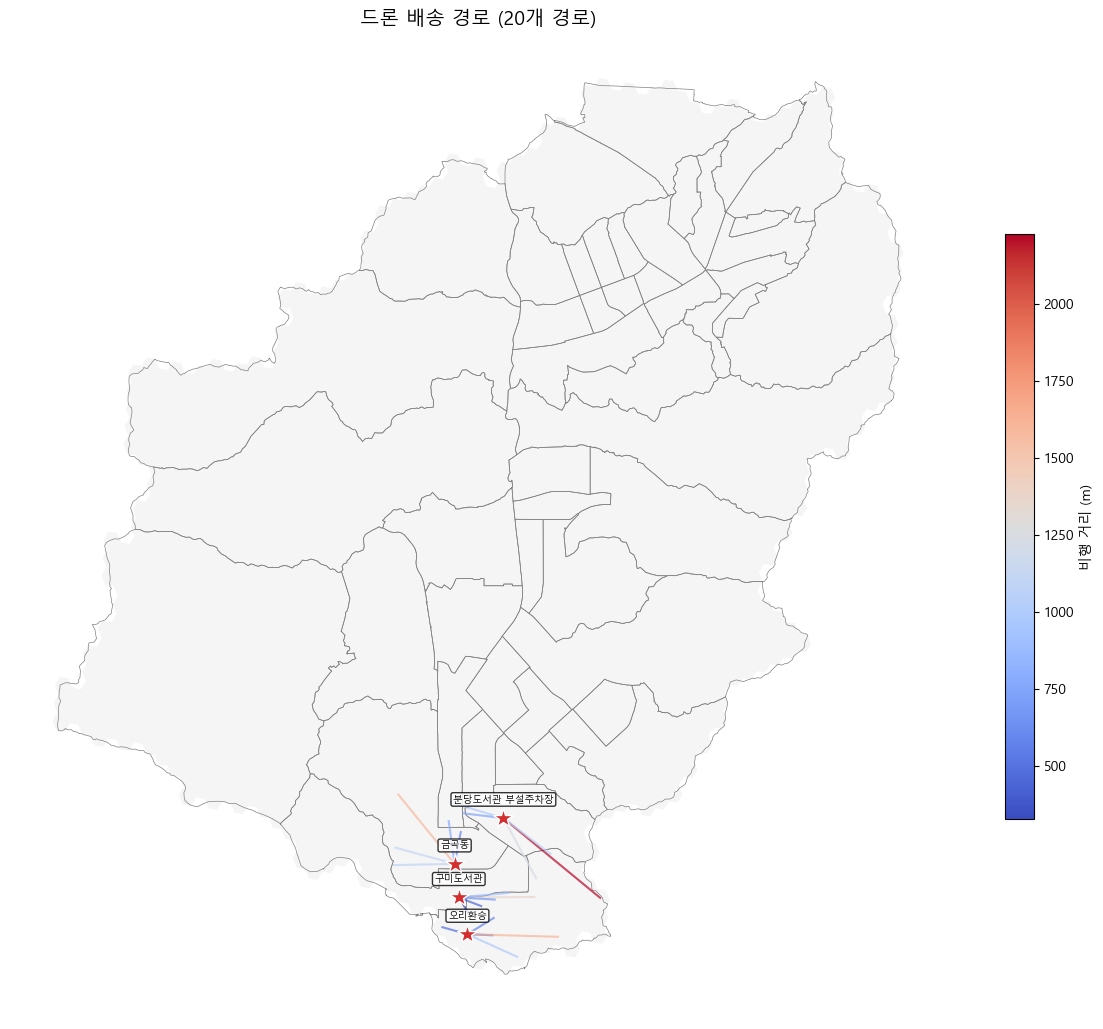

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 배경: 행정동 + terrain zone
seongnam.boundary.plot(ax=ax, color="gray", linewidth=0.5)

# terrain zone 배경
if "terrain_zone" in grid.columns:
    zone_colors = {"Green": "#C8E6C9", "Yellow": "#FFF9C4", "Red": "#FFCDD2", "Unknown": "#E0E0E0"}
    for zone, color in zone_colors.items():
        zone_cells = grid[grid["terrain_zone"] == zone]
        if len(zone_cells) > 0:
            zone_cells.plot(ax=ax, color=color, alpha=0.3, edgecolor="none")

# 드론 경로 (거리에 따른 색상)
gdf_routes.plot(
    ax=ax, column="distance_m", cmap="coolwarm", linewidth=1.5, alpha=0.7,
    legend=True, legend_kwds={"label": "비행 거리 (m)", "shrink": 0.5},
)

# 거점 마커
for _, hub in hubs.iterrows():
    ax.plot(hub.geometry.x, hub.geometry.y, "*", color="#D32F2F", markersize=15,
            markeredgecolor="white", markeredgewidth=1, zorder=10)
    ax.annotate(hub["name"][:12], (hub.geometry.x, hub.geometry.y),
                fontsize=7, ha="center", va="bottom",
                xytext=(0, 10), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

ax.set_title(f"드론 배송 경로 ({len(gdf_routes)}개 경로)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6. 저장

In [7]:
# 경로 GeoPackage 저장
gdf_routes.to_file(OUT / "drone_routes.gpkg", driver="GPKG")

# 경로 요약 CSV (Tableau용)
route_summary = gdf_routes.drop(columns="geometry").copy()
route_summary.to_csv(OUT / "delivery_routes_summary.csv", index=False, encoding="utf-8-sig")

# 거점별 집계 통계
hub_stats = gdf_routes.groupby("hub_name").agg(
    n_routes=("target_h3", "count"),
    avg_distance=("distance_m", "mean"),
    avg_flight_time=("flight_time_min", "mean"),
    avg_total_time=("total_delivery_min", "mean"),
    max_distance=("distance_m", "max"),
).round(1).reset_index()
hub_stats.to_csv(OUT / "hub_delivery_stats.csv", index=False, encoding="utf-8-sig")

print(f"저장 완료:")
print(f"  {OUT / 'drone_routes.gpkg'} ({len(gdf_routes)} 경로)")
print(f"  {OUT / 'delivery_routes_summary.csv'}")
print(f"  {OUT / 'hub_delivery_stats.csv'}")

print(f"\n=== 거점별 요약 ===")
print(hub_stats.to_string(index=False))

저장 완료:
  C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\drone_routes.gpkg (20 경로)
  C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\delivery_routes_summary.csv
  C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\hub_delivery_stats.csv

=== 거점별 요약 ===
   hub_name  n_routes  avg_distance  avg_flight_time  avg_total_time  max_distance
      구미도서관         5         734.7              0.7             0.7        1352.2
        금곡동         5        1029.6              1.0             1.0        1588.0
분당도서관 부설주차장         5        1246.4              1.2             1.2        2228.2
       오리환승         5         819.9              0.8             0.8        1617.2
